# Solar filament segmentation: complete reproducible pipeline

Sijan Regmi. This notebook documents the full image-processing pipeline, calibration, held-out evaluation, and test inference. It uses the downloaded competition data and saved scalar configuration. No pretrained weights or external data are needed.

Install `requirements.txt` in a virtual environment, then select that Python kernel. Run from the project directory or its `notebooks/` subdirectory. For Kaggle, attach the competition data and upload the source package; point `DATA` to the attached `MAGFiLO_1.0_Kaggle_2026` directory. This local notebook has been executed; Kaggle execution is not claimed.


In [1]:
from pathlib import Path
import sys, json, os
ROOT = Path.cwd()
if not (ROOT / 'filament').is_dir(): ROOT = ROOT.parent
assert (ROOT / 'filament').is_dir(), 'Run from the extracted project directory'
sys.path.insert(0, str(ROOT))
DATA = ROOT / 'MAGFiLO_1.0_Kaggle_2026'
assert DATA.is_dir(), 'Extract the competition ZIP or set DATA to its root'
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'work/matplotlib'))
from filament import core, run
print('Data root:', DATA)


Data root: /Users/sijanregmi/Desktop/Projects/Kaggle/Project1/MAGFiLO_1.0_Kaggle_2026


## 1. Grouped partition and supervision

Images from the same capture date stay together, including all independent annotator records. The 111-image calibration subset belongs to the 568-image development partition; 139 images are held out. Only segmentation polygons supervise parameter selection. Spines and chirality labels are unused.


In [2]:
split = json.loads((ROOT/'configs/split.json').read_text())
assert not {x[:8] for x in split['training']} & {x[:8] for x in split['validation']}
{k:len(v) for k,v in split.items() if isinstance(v,list)}


{'validation': 139, 'calibration': 111, 'training': 568}

## 2. Calibrate parameters (optional full rerun)

The complete search evaluates 32 initial and 64 refinement configurations at native resolution. It takes several minutes on the reference laptop. The saved calibration table records every trial. Set `RECALIBRATE=True` to reproduce selection before evaluating. Defaults preserve the already-measured configuration and avoid an unnecessary duplicate search.


In [3]:
RECALIBRATE = False
if RECALIBRATE:
    run.make_split(DATA)
    run.calibrate(DATA, initial_only=True)
    run.calibrate(DATA)
calibration = json.loads((ROOT/'results/calibration.json').read_text())
config = json.loads((ROOT/'configs/model.json').read_text())
print('Selected configuration:', config)
print('Calibration PQ:', calibration['trials'][0]['pq'])


Selected configuration: {'scale': 2, 'threshold': 0.04, 'closing_radius': 0, 'min_area': 800, 'max_area': 100000, 'min_elongation': 2.0}
Calibration PQ: 0.176179273119942


## 3. Inspect inference

The image is normalized to [0,1], the solar disk is inferred and eroded, and a relative Gaussian brightness deficit is thresholded. Morphological closing groups adjacent dark pixels; area-filtered connected components become distinct instances.


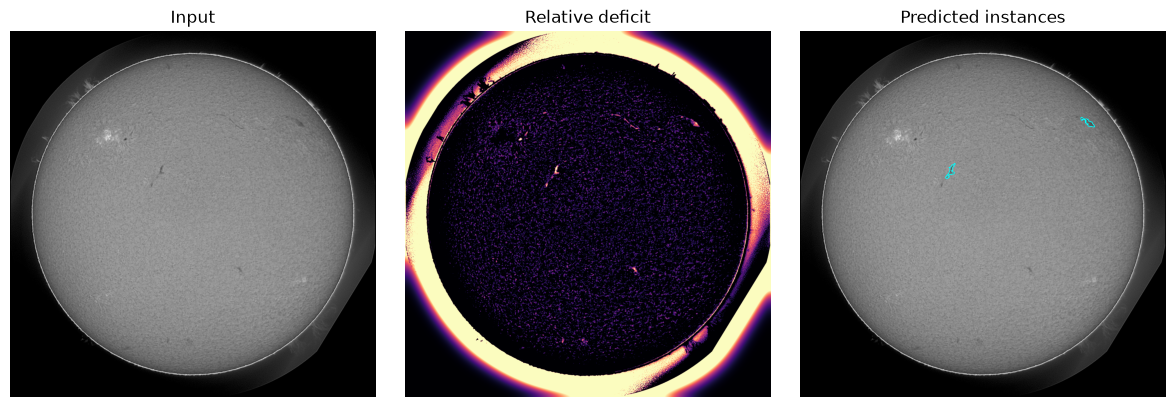

In [4]:
import matplotlib.pyplot as plt
import numpy as np
name = split['validation'][0]
im, disk, contrasts = core.contrast_maps(DATA/'train/train_images'/name)
labels, accepted = core.predict_from_maps(disk, contrasts, config)
fig, axes = plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(im,cmap='gray'); axes[0].set_title('Input')
axes[1].imshow(contrasts[config['scale']],cmap='magma',vmin=0,vmax=.3); axes[1].set_title('Relative deficit')
axes[2].imshow(im,cmap='gray'); axes[2].contour(np.isin(labels,accepted),levels=[.5],colors='cyan',linewidths=.5); axes[2].set_title('Predicted instances')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


## 4. Held-out evaluation

The following runs the frozen configuration on all validation images. PQ follows the official notebook, with strict IoU > 0.5 and pooled counts across annotator–image records. Uncertainty uses a date-cluster bootstrap. This is not a Kaggle leaderboard score.


In [5]:
run.evaluate(DATA)
validation = json.loads((ROOT/'results/validation.json').read_text())
validation['summary']


evaluate 20/139
evaluate 40/139
evaluate 60/139
evaluate 80/139
evaluate 100/139
evaluate 120/139
{'tp': 444, 'fp': 1160, 'fn': 1114, 'sum_iou': 283.9002175665854, 'pq': 0.17957003008639177, 'pq_bootstrap_95ci': [0.16017038562691593, 0.19923630644181592], 'images': 139, 'annotation_sets': 222, 'date_clusters': 131, 'total_seconds': 54.4081449508667, 'bootstrap_seed': 2026, 'config': {'scale': 2, 'threshold': 0.04, 'closing_radius': 0, 'min_area': 800, 'max_area': 100000, 'min_elongation': 2.0}}


{'tp': 444,
 'fp': 1160,
 'fn': 1114,
 'sum_iou': 283.9002175665854,
 'pq': 0.17957003008639177,
 'pq_bootstrap_95ci': [0.16017038562691593, 0.19923630644181592],
 'images': 139,
 'annotation_sets': 222,
 'date_clusters': 131,
 'total_seconds': 54.4081449508667,
 'bootstrap_seed': 2026,
 'config': {'scale': 2,
  'threshold': 0.04,
  'closing_radius': 0,
  'min_area': 800,
  'max_area': 100000,
  'min_elongation': 2.0}}

## 5. Test inference and submission verification

All 180 test images are processed. Each predicted filament gets a unique source-image suffix and COCO compressed RLE. There are no dummy masks. The verifier decodes every mask, checks dimensions and identifiers, and checks canonical re-encoding.


In [6]:
run.predict(DATA)
verification = json.loads((ROOT/'results/submission-verification.json').read_text())
verification


predict 20/180
predict 40/180
predict 60/180
predict 80/180
predict 100/180
predict 120/180
predict 140/180
predict 160/180
predict 180/180
{'status': 'passed', 'rows': 1312, 'test_images_processed': 180, 'images_with_predictions': 175, 'images_without_predictions': ['20170516134450Bh', '20180507140210Th', '20181030230030Lh', '20200310113230Ch', '20211214174010Mh'], 'sha256': '65ec7be6fdc2d0a3a47675b897b55fb13506dcc68951de209227065edbba69ab'}


{'status': 'passed',
 'rows': 1312,
 'test_images_processed': 180,
 'images_with_predictions': 175,
 'images_without_predictions': ['20170516134450Bh',
  '20180507140210Th',
  '20181030230030Lh',
  '20200310113230Ch',
  '20211214174010Mh'],
 'sha256': '65ec7be6fdc2d0a3a47675b897b55fb13506dcc68951de209227065edbba69ab'}

## 6. Diagnostics and report

The report includes overlap distributions, fragmentation/merging counts, uncertainty, and validation overlays. Generate figures with `python scripts/make_figures.py`, then run `python scripts/build_report.py` and compile `report/main.tex` with pdfLaTeX/BibTeX. See README for full commands.

Before submitting, review false positives, missing fine structures, grouping errors, and the participant-understanding walkthrough. Publication and the organizers' final form are separate from generating a local CSV.
